# Feature Engineering
### Goal: Use past sales data + external information to predict future `unit_sales`

---

We have **4 datasets**:

| File | What it contains |
|---|---|
| `timeseries.csv` | Daily sales numbers — this is what we want to predict |
| `oil.csv` | Daily crude oil price — oil affects how much people spend |
| `holidays.csv` | Public holiday dates in Ecuador |
| `stores.csv` | Store locations (city and region) |

By the end of this notebook you will have:
1. Merged all four datasets into one table
2. Created new features the model can learn from

---
## Step 1 — Install & Import Libraries

In [1]:
# Run this cell first — it loads the tools we need

# pandas lets us work with tables (like Excel, but in Python)
import pandas as pd

# numpy lets us do math on whole columns at once
import numpy as np

# matplotlib lets us draw charts
import matplotlib.pyplot as plt

# os lets us build file paths that work on any computer
import os

print("All libraries loaded successfully!")

All libraries loaded successfully!


---
## Step 2 — Set the Data Folder

Change `DATA_DIR` below to match the folder where your CSV files are saved.

In [2]:
# Change this to the folder where your CSV files are saved
# Example on Windows: DATA_DIR = 'C:/Users/YourName/Downloads/data'
# Example on Mac:     DATA_DIR = '/Users/YourName/Downloads/data'
# If the CSV files are in a 'data' folder next to this notebook, leave it as is:

DATA_DIR = 'C:\\Users\\tthem\\timeseries-april\\data'

print("Looking for files in:", DATA_DIR)

Looking for files in: C:\Users\tthem\timeseries-april\data


---
## Step 3 — Load the Data

We load each CSV file into a pandas **DataFrame** (a table with rows and columns).

In [3]:
# Load each CSV file into a separate table

# Sales data — one row per day
timeseries = pd.read_csv(os.path.join(DATA_DIR, 'timeseries.csv'))

# Oil price data — one row per day
oil = pd.read_csv(os.path.join(DATA_DIR, 'oil.csv'))

# Holiday dates
holidays = pd.read_csv(os.path.join(DATA_DIR, 'holidays.csv'))

# Store information (city, region)
stores = pd.read_csv(os.path.join(DATA_DIR, 'stores.csv'))

print("Files loaded!")
print("Sales rows:", len(timeseries))
print("Oil rows:", len(oil))
print("Holiday rows:", len(holidays))
print("Store rows:", len(stores))

Files loaded!
Sales rows: 452
Oil rows: 1218
Holiday rows: 350
Store rows: 54


---
## Step 4 — Explore the Data

Always look at your data before doing anything with it.  
`.head()` shows the first 5 rows of a table.

In [4]:
# Look at the first 5 rows of the sales table
print("=== Sales data (timeseries) ===")
print(timeseries.head())

# Look at the first 5 rows of the oil table
print("=== Oil price data ===")
print(oil.head())

# Look at the first 5 rows of the holidays table
print("=== Holidays data ===")
print(holidays.head())

=== Sales data (timeseries) ===
         date  unit_sales
0  2013-01-02       582.0
1  2013-01-03       310.0
2  2013-01-04       338.0
3  2013-01-05       654.0
4  2013-01-06       979.0
=== Oil price data ===
         date  dcoilwtico
0  2013-01-01         NaN
1  2013-01-02       93.14
2  2013-01-03       92.97
3  2013-01-04       93.12
4  2013-01-07       93.20
=== Holidays data ===
         date    locale locale_name                    description
0  2012-03-02     Local       Manta             Fundacion de Manta
1  2012-04-01  Regional    Cotopaxi  Provincializacion de Cotopaxi
2  2012-04-12     Local      Cuenca            Fundacion de Cuenca
3  2012-04-14     Local    Libertad      Cantonizacion de Libertad
4  2012-04-21     Local    Riobamba      Cantonizacion de Riobamba


In [5]:
# Check for missing values in each table
# A missing value means there is no data in that cell

print("Missing values in timeseries:")
print(timeseries.isnull().sum())

print("Missing values in oil:")
print(oil.isnull().sum())
# The oil table has some missing prices — we will fix this later

Missing values in timeseries:
date          0
unit_sales    0
dtype: int64
Missing values in oil:
date           0
dcoilwtico    43
dtype: int64


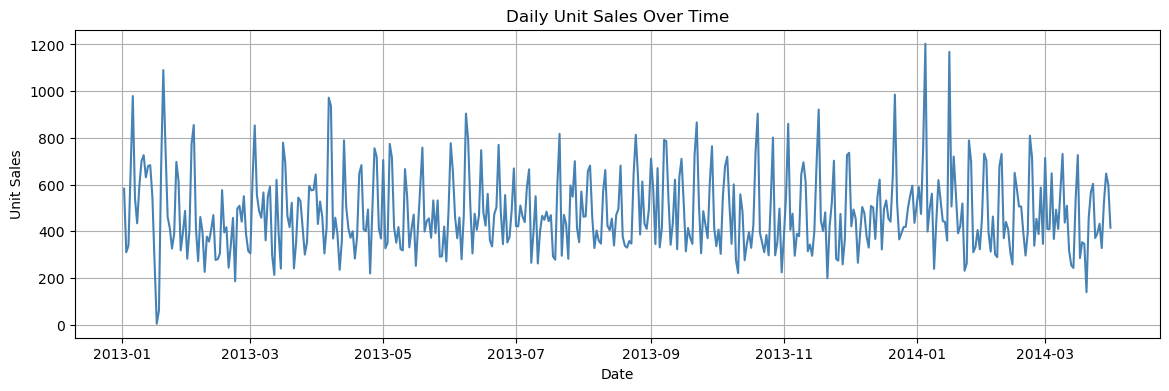

In [6]:
# Plot the sales over time so we can see patterns

timeseries['date'] = pd.to_datetime(timeseries['date'])

plt.figure(figsize=(14, 4))
plt.plot(timeseries['date'], timeseries['unit_sales'], color='steelblue')
plt.title('Daily Unit Sales Over Time')
plt.xlabel('Date')
plt.ylabel('Unit Sales')
plt.grid(True)
plt.show()

# Look for:
# - Is there an overall trend (going up or down over time)?
# - Are there repeating weekly patterns?
# - Are there unusual spikes (could be holidays)?

---
## Step 5 — Merge the Datasets

Right now we have 4 separate tables. We need to combine them into one table so the model can use all the information together.

**How merging works:**  
Think of it like a VLOOKUP in Excel — we match rows from different tables using a shared column (the date).

In [7]:
# Convert the date column to a proper date format in all tables
# This makes sure dates match correctly when we merge

timeseries['date'] = pd.to_datetime(timeseries['date'])
oil['date']        = pd.to_datetime(oil['date'])
holidays['date']   = pd.to_datetime(holidays['date'])

print("Date columns converted.")

Date columns converted.


In [8]:
# Start with the sales table as our main table
df = timeseries.copy()

# Sort by date from oldest to newest (important for lag features later)
df = df.sort_values('date')
df = df.reset_index(drop=True)

print("Main table ready. Shape:", df.shape)
print(df.head())

Main table ready. Shape: (452, 2)
        date  unit_sales
0 2013-01-02       582.0
1 2013-01-03       310.0
2 2013-01-04       338.0
3 2013-01-05       654.0
4 2013-01-06       979.0


In [9]:
# Merge 1: Add oil prices to our main table
# how='left' means: keep every row from df, and add oil price where the date matches
# If no oil price exists for that date, the value will be blank (NaN) for now

df = df.merge(oil, on='date', how='left')

print("After adding oil prices. Shape:", df.shape)
print(df.head())

After adding oil prices. Shape: (452, 3)
        date  unit_sales  dcoilwtico
0 2013-01-02       582.0       93.14
1 2013-01-03       310.0       92.97
2 2013-01-04       338.0       93.12
3 2013-01-05       654.0         NaN
4 2013-01-06       979.0         NaN


In [10]:
# Merge 2: Add a flag for National Holidays
# First, filter the holidays table to only keep National holidays

national_holidays = holidays[holidays['locale'] == 'National']
national_holidays = national_holidays[['date']].drop_duplicates()
national_holidays['is_national_holiday'] = 1

# Now merge this into our main table
df = df.merge(national_holidays, on='date', how='left')

# Any date that is NOT a national holiday will show NaN — replace with 0
df['is_national_holiday'] = df['is_national_holiday'].fillna(0)
df['is_national_holiday'] = df['is_national_holiday'].astype(int)

print("National holiday flag added.")
print("Number of national holidays in data:", df['is_national_holiday'].sum())

National holiday flag added.
Number of national holidays in data: 22


In [11]:
# Merge 3: Add a flag for Regional Holidays

regional_holidays = holidays[holidays['locale'] == 'Regional']
regional_holidays = regional_holidays[['date']].drop_duplicates()
regional_holidays['is_regional_holiday'] = 1

df = df.merge(regional_holidays, on='date', how='left')
df['is_regional_holiday'] = df['is_regional_holiday'].fillna(0)
df['is_regional_holiday'] = df['is_regional_holiday'].astype(int)

print("Regional holiday flag added.")

Regional holiday flag added.


In [12]:
# Merge 4: Add a flag for Local Holidays

local_holidays = holidays[holidays['locale'] == 'Local']
local_holidays = local_holidays[['date']].drop_duplicates()
local_holidays['is_local_holiday'] = 1

df = df.merge(local_holidays, on='date', how='left')
df['is_local_holiday'] = df['is_local_holiday'].fillna(0)
df['is_local_holiday'] = df['is_local_holiday'].astype(int)

print("Local holiday flag added.")
print()
print("Our merged table now looks like this:")
print(df.head())

Local holiday flag added.

Our merged table now looks like this:
        date  unit_sales  dcoilwtico  is_national_holiday  \
0 2013-01-02       582.0       93.14                    0   
1 2013-01-03       310.0       92.97                    0   
2 2013-01-04       338.0       93.12                    0   
3 2013-01-05       654.0         NaN                    1   
4 2013-01-06       979.0         NaN                    0   

   is_regional_holiday  is_local_holiday  
0                    0                 0  
1                    0                 0  
2                    0                 0  
3                    0                 0  
4                    0                 0  


In [13]:
# Fix missing oil prices
# Some dates have no oil price (e.g. weekends when markets are closed)
# interpolate() fills those gaps by estimating a value between the two nearest prices

df['dcoilwtico'] = df['dcoilwtico'].interpolate(method='linear')

# Fill any remaining blanks at the very start or end
df['dcoilwtico'] = df['dcoilwtico'].fillna(method='ffill')
df['dcoilwtico'] = df['dcoilwtico'].fillna(method='bfill')

print("Missing oil prices fixed.")
print("Missing values remaining:", df.isnull().sum().sum())

Missing oil prices fixed.
Missing values remaining: 0


C:\Users\tthem\AppData\Local\Temp\ipykernel_23132\188450280.py:8: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df['dcoilwtico'] = df['dcoilwtico'].fillna(method='ffill')
C:\Users\tthem\AppData\Local\Temp\ipykernel_23132\188450280.py:9: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df['dcoilwtico'] = df['dcoilwtico'].fillna(method='bfill')


---
## Step 6 — Feature Engineering

**What is feature engineering?**  
Machine learning models learn from numbers, not from raw dates like "2013-01-15".  
We need to extract useful numbers from the date and from past sales.

We will create 5 groups of features:
1. Calendar features — what day, month, weekday is it?
2. Lag features — what were sales in the past?
3. Rolling window features — what is the recent trend?
4. Oil price features — how has oil price changed?
5. Holiday features — already created

### 6a — Calendar Features

In [14]:
# Extract date parts that the model can learn from

# Year (e.g. 2013, 2014)
df['year'] = df['date'].dt.year

# Month number (1 = January, 12 = December)
df['month'] = df['date'].dt.month

# Day of the month (1 to 31)
df['day'] = df['date'].dt.day

# Day of the week (0 = Monday, 6 = Sunday)
df['dayofweek'] = df['date'].dt.dayofweek

# Quarter of the year (1, 2, 3, or 4)
df['quarter'] = df['date'].dt.quarter

# Week number of the year (1 to 52)
df['week_of_year'] = df['date'].dt.isocalendar().week.astype(int)

print("Calendar features added:")
print(df[['date', 'year', 'month', 'day', 'dayofweek', 'quarter', 'week_of_year']].head(8))

Calendar features added:
        date  year  month  day  dayofweek  quarter  week_of_year
0 2013-01-02  2013      1    2          2        1             1
1 2013-01-03  2013      1    3          3        1             1
2 2013-01-04  2013      1    4          4        1             1
3 2013-01-05  2013      1    5          5        1             1
4 2013-01-06  2013      1    6          6        1             1
5 2013-01-07  2013      1    7          0        1             2
6 2013-01-08  2013      1    8          1        1             2
7 2013-01-09  2013      1    9          2        1             2


In [15]:
# Create simple yes/no (1 or 0) flags from calendar info

# Is it a weekend? (Saturday = 5, Sunday = 6)
df['is_weekend'] = 0
df.loc[df['dayofweek'] >= 5, 'is_weekend'] = 1

# Is it the first day of the month?
df['is_month_start'] = df['date'].dt.is_month_start.astype(int)

# Is it the last day of the month?
df['is_month_end'] = df['date'].dt.is_month_end.astype(int)

print("Weekend and month-boundary flags added:")
print(df[['date', 'dayofweek', 'is_weekend', 'is_month_start', 'is_month_end']].head(10))

Weekend and month-boundary flags added:
        date  dayofweek  is_weekend  is_month_start  is_month_end
0 2013-01-02          2           0               0             0
1 2013-01-03          3           0               0             0
2 2013-01-04          4           0               0             0
3 2013-01-05          5           1               0             0
4 2013-01-06          6           1               0             0
5 2013-01-07          0           0               0             0
6 2013-01-08          1           0               0             0
7 2013-01-09          2           0               0             0
8 2013-01-10          3           0               0             0
9 2013-01-11          4           0               0             0


### 6b — Lag Features

A **lag feature** is simply a past value of sales copied into the current row.  
For example, `lag_1` on January 8th will contain the sales from January 7th.

This is useful because yesterday's sales is often the best clue for today's sales.

In [16]:
# lag_1 = sales from 1 day ago (yesterday)
df['lag_1'] = df['unit_sales'].shift(1)

# lag_7 = sales from 7 days ago (same weekday last week)
df['lag_7'] = df['unit_sales'].shift(7)

# lag_14 = sales from 14 days ago (same weekday two weeks ago)
df['lag_14'] = df['unit_sales'].shift(14)

# lag_30 = sales from 30 days ago (roughly same day last month)
df['lag_30'] = df['unit_sales'].shift(30)

print("Lag features added:")
print(df[['date', 'unit_sales', 'lag_1', 'lag_7', 'lag_14', 'lag_30']].head(15))
print()
print("Note: The first rows show NaN because there is no past data for them yet.")

Lag features added:
         date  unit_sales  lag_1  lag_7  lag_14  lag_30
0  2013-01-02       582.0    NaN    NaN     NaN     NaN
1  2013-01-03       310.0  582.0    NaN     NaN     NaN
2  2013-01-04       338.0  310.0    NaN     NaN     NaN
3  2013-01-05       654.0  338.0    NaN     NaN     NaN
4  2013-01-06       979.0  654.0    NaN     NaN     NaN
5  2013-01-07       541.0  979.0    NaN     NaN     NaN
6  2013-01-08       434.0  541.0    NaN     NaN     NaN
7  2013-01-09       593.0  434.0  582.0     NaN     NaN
8  2013-01-10       700.0  593.0  310.0     NaN     NaN
9  2013-01-11       726.0  700.0  338.0     NaN     NaN
10 2013-01-12       631.0  726.0  654.0     NaN     NaN
11 2013-01-13       679.0  631.0  979.0     NaN     NaN
12 2013-01-14       683.0  679.0  541.0     NaN     NaN
13 2013-01-15       547.0  683.0  434.0     NaN     NaN
14 2013-01-16       265.0  547.0  593.0   582.0     NaN

Note: The first rows show NaN because there is no past data for them yet.


### 6c — Rolling Window Features

A **rolling average** is the average of the last N days of sales.  
It smooths out day-to-day ups and downs so the model can see the overall trend.

Example: the 7-day rolling average on day 10 = average of days 3 through 9.

In [17]:
# We shift by 1 first to make sure we only use PAST data
# (we never want to accidentally include today's sales when predicting today)
past_sales = df['unit_sales'].shift(1)

# Average sales over the last 7 days
df['rolling_7d_mean'] = past_sales.rolling(window=7).mean()

# Average sales over the last 14 days
df['rolling_14d_mean'] = past_sales.rolling(window=14).mean()

# Average sales over the last 30 days
df['rolling_30d_mean'] = past_sales.rolling(window=30).mean()

# Standard deviation over the last 7 days
# This measures how much sales varied — high std means unpredictable sales
df['rolling_7d_std'] = past_sales.rolling(window=7).std()

print("Rolling window features added:")
print(df[['date', 'unit_sales', 'rolling_7d_mean', 'rolling_14d_mean', 'rolling_7d_std']].head(20))

Rolling window features added:
         date  unit_sales  rolling_7d_mean  rolling_14d_mean  rolling_7d_std
0  2013-01-02       582.0              NaN               NaN             NaN
1  2013-01-03       310.0              NaN               NaN             NaN
2  2013-01-04       338.0              NaN               NaN             NaN
3  2013-01-05       654.0              NaN               NaN             NaN
4  2013-01-06       979.0              NaN               NaN             NaN
5  2013-01-07       541.0              NaN               NaN             NaN
6  2013-01-08       434.0              NaN               NaN             NaN
7  2013-01-09       593.0       548.285714               NaN      228.013680
8  2013-01-10       700.0       549.857143               NaN      228.322454
9  2013-01-11       726.0       605.571429               NaN      206.587235
10 2013-01-12       631.0       661.000000               NaN      171.984495
11 2013-01-13       679.0       657.714286   

### 6d — Oil Price Features

Ecuador depends heavily on oil revenue. When oil prices drop, the economy is affected and people tend to spend less.  
We use the **previous day's** oil price (not today's) because economic effects take time.

In [18]:
# Oil price from yesterday
df['oil_lag_1'] = df['dcoilwtico'].shift(1)

# Average oil price over the last 7 days (smoothed trend)
df['oil_rolling_7d_mean'] = df['dcoilwtico'].shift(1).rolling(window=7).mean()

print("Oil price features added:")
print(df[['date', 'dcoilwtico', 'oil_lag_1', 'oil_rolling_7d_mean']].head(15))

Oil price features added:
         date  dcoilwtico  oil_lag_1  oil_rolling_7d_mean
0  2013-01-02   93.140000        NaN                  NaN
1  2013-01-03   92.970000  93.140000                  NaN
2  2013-01-04   93.120000  92.970000                  NaN
3  2013-01-05   93.146667  93.120000                  NaN
4  2013-01-06   93.173333  93.146667                  NaN
5  2013-01-07   93.200000  93.173333                  NaN
6  2013-01-08   93.210000  93.200000                  NaN
7  2013-01-09   93.080000  93.210000            93.137143
8  2013-01-10   93.810000  93.080000            93.128571
9  2013-01-11   93.600000  93.810000            93.248571
10 2013-01-12   93.823333  93.600000            93.317143
11 2013-01-13   94.046667  93.823333            93.413810
12 2013-01-14   94.270000  94.046667            93.538571
13 2013-01-15   93.260000  94.270000            93.691429
14 2013-01-16   94.280000  93.260000            93.698571


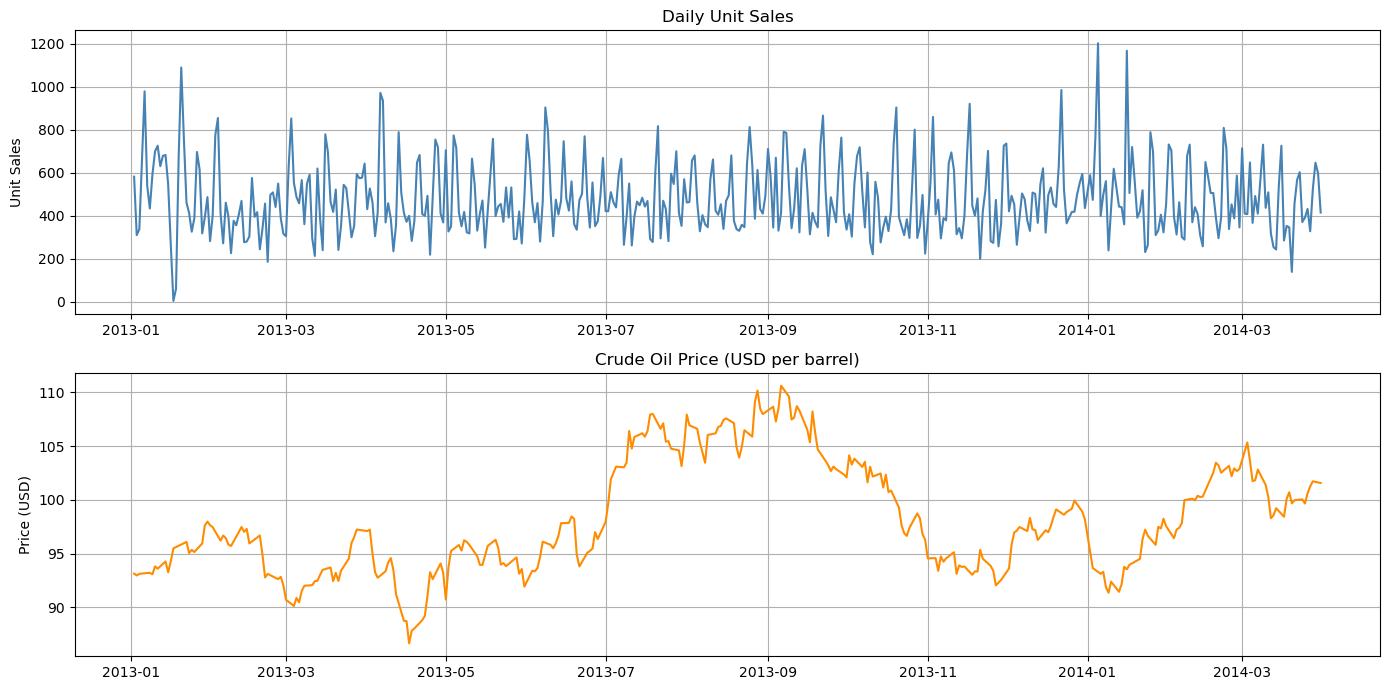

In [19]:
# Visualise oil price vs unit sales side by side

fig, axes = plt.subplots(2, 1, figsize=(14, 7))

axes[0].plot(df['date'], df['unit_sales'], color='steelblue')
axes[0].set_title('Daily Unit Sales')
axes[0].set_ylabel('Unit Sales')
axes[0].grid(True)

axes[1].plot(df['date'], df['dcoilwtico'], color='darkorange')
axes[1].set_title('Crude Oil Price (USD per barrel)')
axes[1].set_ylabel('Price (USD)')
axes[1].grid(True)

plt.tight_layout()
plt.show()

### 6e — Holiday Features (visualise them)

In [20]:
# Compare average sales on holiday vs non-holiday days

avg_sales_holiday     = df[df['is_national_holiday'] == 1]['unit_sales'].mean()
avg_sales_no_holiday  = df[df['is_national_holiday'] == 0]['unit_sales'].mean()

print("Average sales on National Holiday days: ", round(avg_sales_holiday, 1))
print("Average sales on non-holiday days:      ", round(avg_sales_no_holiday, 1))

Average sales on National Holiday days:  556.2
Average sales on non-holiday days:       476.2


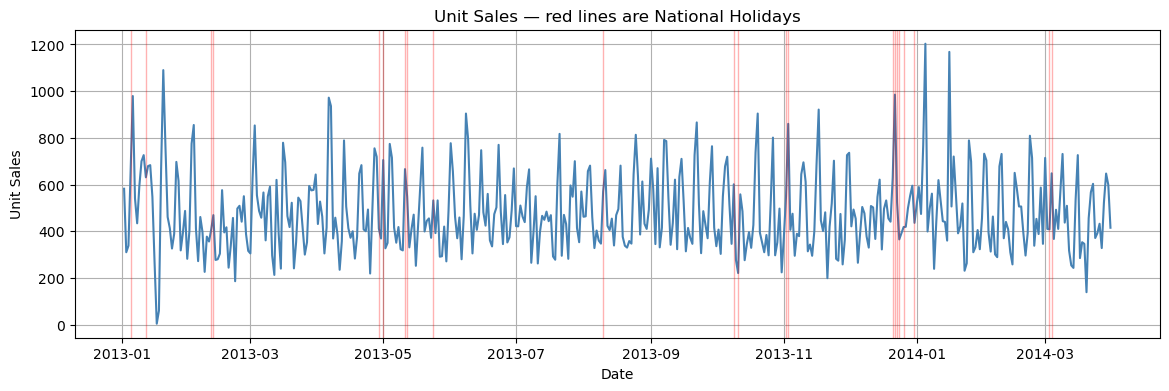

In [21]:
# Plot sales and highlight national holiday dates with a red line

plt.figure(figsize=(14, 4))
plt.plot(df['date'], df['unit_sales'], color='steelblue', label='Unit Sales')

# Draw a vertical red line for every national holiday
holiday_dates = df[df['is_national_holiday'] == 1]['date']
for holiday_date in holiday_dates:
    plt.axvline(x=holiday_date, color='red', alpha=0.3, linewidth=1)

plt.title('Unit Sales — red lines are National Holidays')
plt.xlabel('Date')
plt.ylabel('Unit Sales')
plt.grid(True)
plt.show()

### 7 — View the Updated Timeseries Dataframe

In [22]:
# View the new dataframe with all our features
print(df.head())

        date  unit_sales  dcoilwtico  is_national_holiday  \
0 2013-01-02       582.0   93.140000                    0   
1 2013-01-03       310.0   92.970000                    0   
2 2013-01-04       338.0   93.120000                    0   
3 2013-01-05       654.0   93.146667                    1   
4 2013-01-06       979.0   93.173333                    0   

   is_regional_holiday  is_local_holiday  year  month  day  dayofweek  ...  \
0                    0                 0  2013      1    2          2  ...   
1                    0                 0  2013      1    3          3  ...   
2                    0                 0  2013      1    4          4  ...   
3                    0                 0  2013      1    5          5  ...   
4                    0                 0  2013      1    6          6  ...   

   lag_1  lag_7  lag_14  lag_30  rolling_7d_mean  rolling_14d_mean  \
0    NaN    NaN     NaN     NaN              NaN               NaN   
1  582.0    NaN     NaN 

In [23]:
# Option A: Use '%' as a pipeline to save this dataframe to use in another notebook

%store df

Stored 'df' (DataFrame)


In [24]:
# Option B: Export the dataframe to a new CSV file that we can load later

output_path = os.path.join(DATA_DIR, 'timeseries_with_features.csv')
df.to_csv(output_path, index=False)